# Домашнее задание: мультитаск-маршрутизация тикетов поддержки

## 1. Импорты и настройки

In [1]:
import os
import re
import random
import warnings
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from transformers.utils import logging as hf_logging
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

/opt/anaconda3/envs/notebook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 2. Загрузка данных и фиксированный split

In [2]:
DATA_DIR = Path("data")
TRAIN_IDX_PATH = DATA_DIR / "train_idx.txt"
VAL_IDX_PATH = DATA_DIR / "val_idx.txt"
TEST_IDX_PATH = DATA_DIR / "test_idx.txt"

EXPECTED_SIZES = {
    "train": 49412,
    "val": 6176,
    "test": 6177,
}

dataset = load_dataset("Tobi-Bueck/customer-support-tickets", split="train")
df_all = dataset.to_pandas().reset_index(drop=True)

print(f"Полный размер датасета: {len(df_all):,}")
print("Колонки:", list(df_all.columns))

Полный размер датасета: 61,765
Колонки: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


In [3]:
def pick_column(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    raise ValueError(f"Не найдена колонка. Проверенные кандидаты: {candidates}")

subject_col = pick_column(df_all.columns, ["subject", "ticket_subject", "title"])
body_col = pick_column(df_all.columns, ["body", "message", "description", "ticket_body"])
queue_col = pick_column(df_all.columns, ["queue", "category", "department"])
priority_col = pick_column(df_all.columns, ["priority"])
type_col = pick_column(df_all.columns, ["type", "ticket_type"])
language_col = pick_column(df_all.columns, ["language", "lang"])

print("Выбранные поля:")
print(f"subject:  {subject_col}")
print(f"body:     {body_col}")
print(f"queue:    {queue_col}")
print(f"priority: {priority_col}")
print(f"type:     {type_col}")
print(f"language: {language_col}")

Выбранные поля:
subject:  subject
body:     body
queue:    queue
priority: priority
type:     type
language: language


In [4]:
train_idx = np.loadtxt(TRAIN_IDX_PATH, dtype=int)
val_idx = np.loadtxt(VAL_IDX_PATH, dtype=int)
test_idx = np.loadtxt(TEST_IDX_PATH, dtype=int)

train_df = df_all.iloc[train_idx].copy().reset_index(drop=True)
val_df = df_all.iloc[val_idx].copy().reset_index(drop=True)
test_df = df_all.iloc[test_idx].copy().reset_index(drop=True)

print(f"train: {len(train_df):,}")
print(f"val:   {len(val_df):,}")
print(f"test:  {len(test_df):,}")

assert len(train_df) == EXPECTED_SIZES["train"]
assert len(val_df) == EXPECTED_SIZES["val"]
assert len(test_df) == EXPECTED_SIZES["test"]

train: 49,412
val:   6,176
test:  6,177


## 3. Предобработка

- Нормализуем `subject` и `body`.
- В `type` заменяем пропуски на `Unknown`.
- Формируем объединённый текст `text = subject + [SEP] + body`.

In [5]:
def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def prepare_split(df):
    out = df.copy()
    out[subject_col] = out[subject_col].apply(normalize_text)
    out[body_col] = out[body_col].apply(normalize_text)

    out[queue_col] = out[queue_col].astype(str).str.strip()
    out[priority_col] = out[priority_col].astype(str).str.strip()
    out[type_col] = out[type_col].apply(
        lambda v: "Unknown" if pd.isna(v) or str(v).strip() == "" else str(v).strip()
    )

    out["text"] = (out[subject_col] + " [SEP] " + out[body_col]).str.strip()
    out["text_signature"] = out["text"].apply(
        lambda s: hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()
    )
    return out

train_df = prepare_split(train_df)
val_df = prepare_split(val_df)
test_df = prepare_split(test_df)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: пустых text = {(d['text'].str.len() == 0).sum()}")

train: пустых text = 0
val: пустых text = 0
test: пустых text = 0


## 4. EDA

### 4.1. Общая информация, пропуски, языки

In [6]:
print("Размеры выборок:")
print(f"train={train_df.shape}, val={val_df.shape}, test={test_df.shape}")

missing_train = train_df[[subject_col, body_col, queue_col, priority_col, type_col, language_col]].isna().sum()
print("\nПропуски в train:")
display(missing_train.to_frame("missing"))

print("\nПримеры тикетов:")
display(train_df[[subject_col, body_col, queue_col, priority_col, type_col, language_col]].sample(5, random_state=SEED))

lang_dist = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
], ignore_index=True)
lang_table = pd.crosstab(lang_dist["split"], lang_dist[language_col], normalize="index")

print("\nДоли языков по split:")
display((lang_table * 100).round(2))

Размеры выборок:
train=(49412, 18), val=(6176, 18), test=(6177, 18)

Пропуски в train:


,missing
subject,0
body,0
queue,0
priority,0
type,0
language,0



Примеры тикетов:


,subject,body,queue,priority,type,language
42710,Support Details for Project Management SaaS,Could you provide details on the billing proce...,Billing and Payments,medium,Request,en
16680,Boost Brand Growth Strategies,Is it possible to get insights on digital stra...,Technical Support,high,Request,en
6293,Enhancing Marketing for Red Enterprise Linux D...,"Customer Support, seeking guidance on practice...",Product Support,low,Request,en
7217,,"Sehr geehrter Kundenservice, ich möchte Sie bi...",Product Support,medium,Request,de
16357,Concerning Data Security Incident,There is a potential data breach in the health...,Technical Support,medium,Incident,en



Доли языков по split:


language,de,en
split,,
test,53.91,46.09
train,54.24,45.76
val,54.65,45.35


### 4.2. Распределение целевых классов

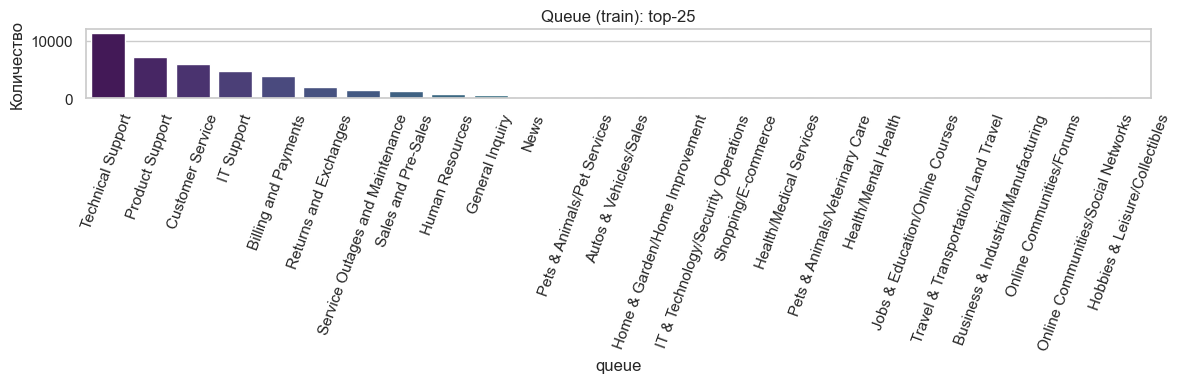

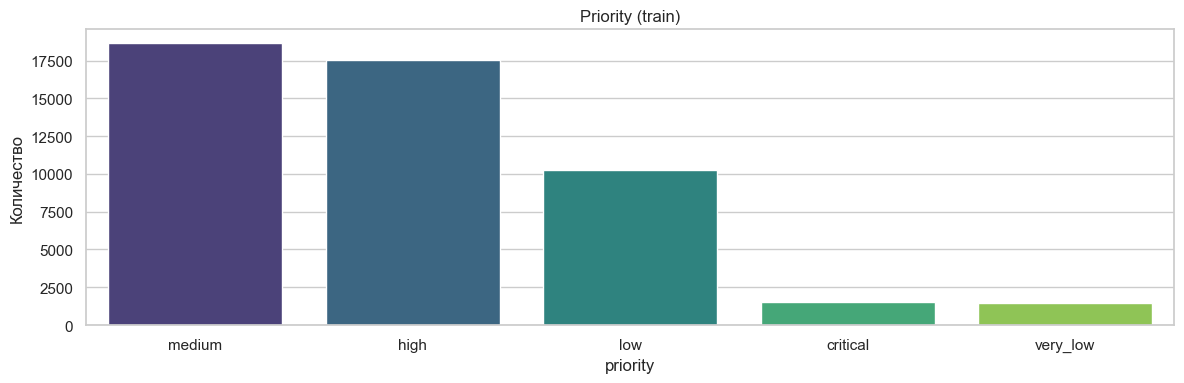

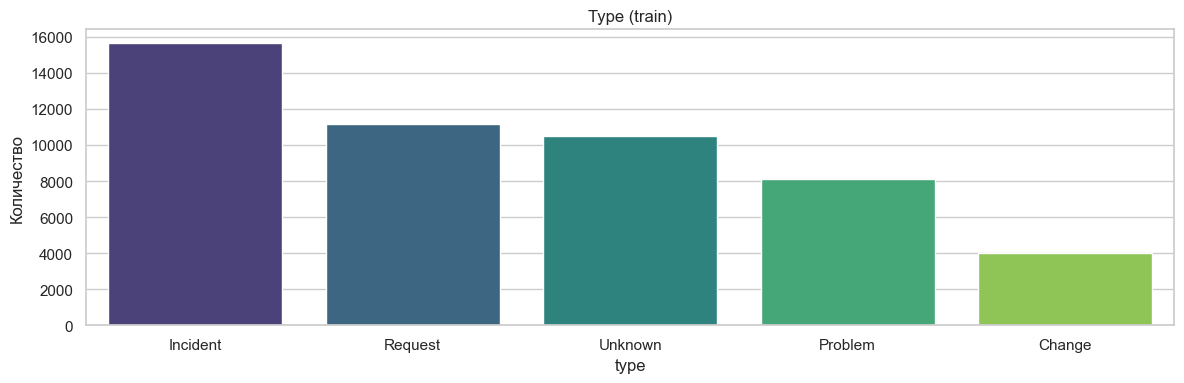

Частоты queue (top-15):


,count
queue,
Technical Support,11354
Product Support,7139
Customer Service,5905
IT Support,4673
Billing and Payments,3853
Returns and Exchanges,1956
Service Outages and Maintenance,1534
Sales and Pre-Sales,1228
Human Resources,730


Частоты queue (bottom-15):


,count
queue,
Games,237
Science/Research,237
Autos & Vehicles/Maintenance,237
Jobs & Education/Recruitment,235
Science/Environmental Science,233
Food & Drink/Restaurants,232
Books & Literature/Fiction,232
Shopping/Retail Stores,226
People & Society/Culture & Society,220


In [7]:
def plot_distribution(series, title, top_n=None, rotate=70):
    vc = series.value_counts()
    if top_n is not None:
        vc = vc.head(top_n)

    plt.figure(figsize=(12, 4))
    sns.barplot(x=vc.index, y=vc.values, palette="viridis")
    plt.title(title)
    plt.ylabel("Количество")
    plt.xlabel(series.name)
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()

plot_distribution(train_df[queue_col], "Queue (train): top-25", top_n=25)
plot_distribution(train_df[priority_col], "Priority (train)", top_n=None, rotate=0)
plot_distribution(train_df[type_col], "Type (train)", top_n=None, rotate=0)

print("Частоты queue (top-15):")
display(train_df[queue_col].value_counts().head(15).to_frame("count"))

print("Частоты queue (bottom-15):")
display(train_df[queue_col].value_counts().tail(15).to_frame("count"))

### 4.3. Дисбаланс классов и редкие классы `queue`

Классов queue: 52
Макс/мин дисбаланс по count: 60.72x
Медианное число объектов в классе: 260

Число редких классов queue (<= 120): 0


,count
queue,


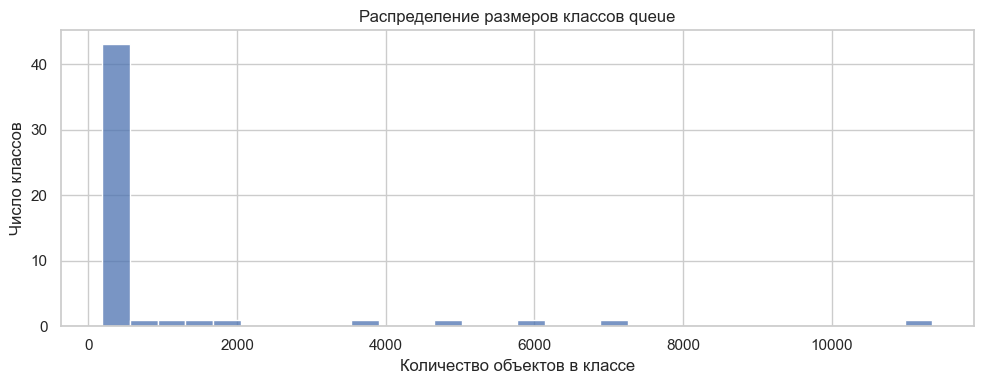

In [8]:
queue_counts = train_df[queue_col].value_counts()

imbalance_ratio = queue_counts.max() / queue_counts.min()
print(f"Классов queue: {queue_counts.shape[0]}")
print(f"Макс/мин дисбаланс по count: {imbalance_ratio:.2f}x")
print(f"Медианное число объектов в классе: {int(queue_counts.median())}")

rare_threshold = 120
rare_queue = queue_counts[queue_counts <= rare_threshold]
print(f"\nЧисло редких классов queue (<= {rare_threshold}): {len(rare_queue)}")
display(rare_queue.sort_values().to_frame("count").head(20))

plt.figure(figsize=(10, 4))
sns.histplot(queue_counts.values, bins=30, color="#4c72b0")
plt.title("Распределение размеров классов queue")
plt.xlabel("Количество объектов в классе")
plt.ylabel("Число классов")
plt.tight_layout()
plt.show()

### 4.4. Анализ длины текстов

Статистика длин (train):


,subject_words,body_words,text_words,subject_chars,body_chars,text_chars
count,49412.000000,49412.000000,49412.000000,49412.000000,49412.000000,49412.000000
mean,5.067696,57.377742,63.445438,43.347142,419.402615,469.663341
std,2.765279,30.999331,31.205693,23.210910,223.609656,226.853867
min,0.000000,0.000000,2.000000,0.000000,0.000000,10.000000
50%,5.000000,57.000000,63.000000,43.000000,415.000000,465.000000
90%,8.000000,93.000000,100.000000,69.000000,702.000000,760.000000
95%,9.000000,102.000000,109.000000,79.000000,759.000000,822.000000
99%,12.000000,138.000000,144.000000,100.000000,945.890000,1003.000000
max,77.000000,281.000000,284.000000,675.000000,2259.000000,2290.000000


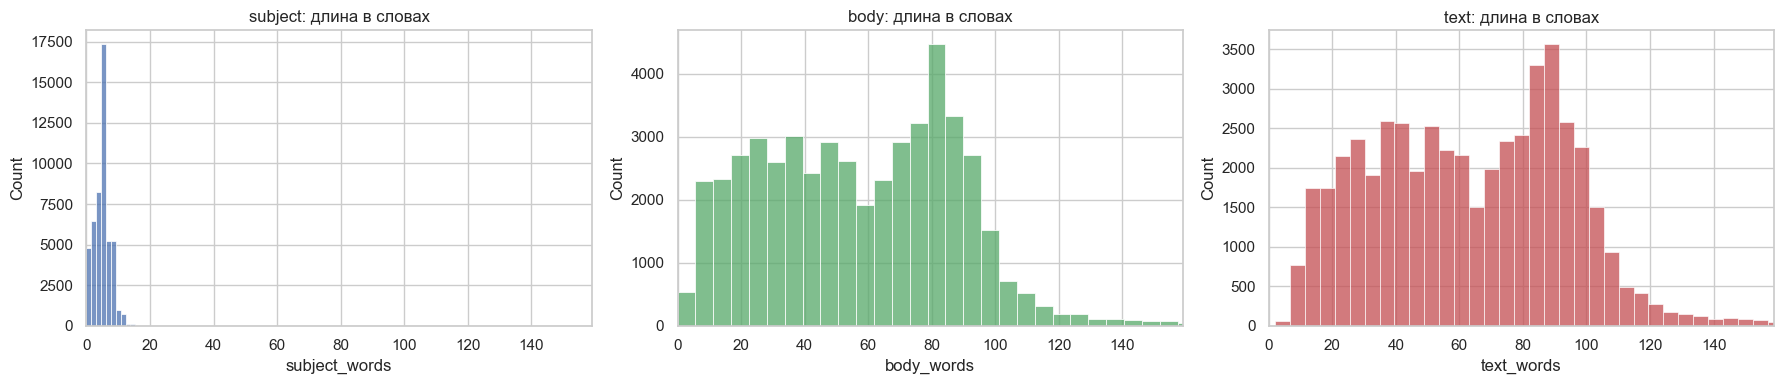

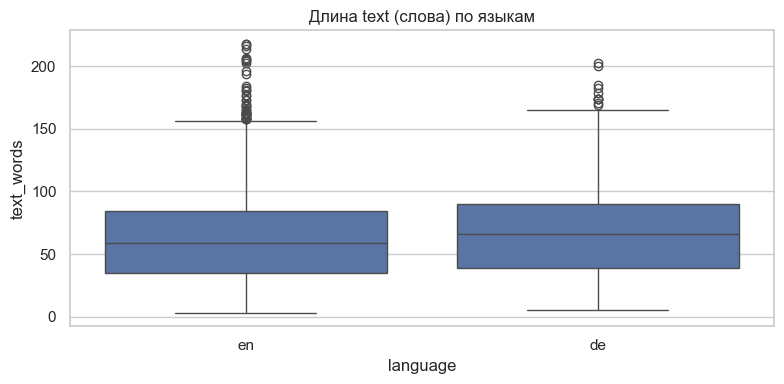

In [9]:
def word_len(s):
    s = str(s).strip()
    return len(s.split()) if s else 0

for d in [train_df, val_df, test_df]:
    d["subject_words"] = d[subject_col].apply(word_len)
    d["body_words"] = d[body_col].apply(word_len)
    d["text_words"] = d["text"].apply(word_len)

    d["subject_chars"] = d[subject_col].str.len()
    d["body_chars"] = d[body_col].str.len()
    d["text_chars"] = d["text"].str.len()

print("Статистика длин (train):")
display(train_df[["subject_words", "body_words", "text_words", "subject_chars", "body_chars", "text_chars"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(train_df["subject_words"], bins=50, ax=axes[0], color="#4c72b0")
axes[0].set_title("subject: длина в словах")

sns.histplot(train_df["body_words"], bins=50, ax=axes[1], color="#55a868")
axes[1].set_title("body: длина в словах")

sns.histplot(train_df["text_words"], bins=60, ax=axes[2], color="#c44e52")
axes[2].set_title("text: длина в словах")

for ax in axes:
    ax.set_xlim(0, np.percentile(train_df["text_words"], 99.5))

plt.tight_layout()
plt.show()

sample_for_box = train_df[[language_col, "text_words"]].copy()
if len(sample_for_box) > 12000:
    sample_for_box = sample_for_box.sample(12000, random_state=SEED)

plt.figure(figsize=(8, 4))
sns.boxplot(data=sample_for_box, x=language_col, y="text_words")
plt.title("Длина text (слова) по языкам")
plt.tight_layout()
plt.show()

### 4.5. Проверка дублей и утечек между split

In [10]:
train_dup = train_df["text_signature"].duplicated().sum()
val_dup = val_df["text_signature"].duplicated().sum()
test_dup = test_df["text_signature"].duplicated().sum()

print(f"Дубликаты внутри train: {train_dup}")
print(f"Дубликаты внутри val:   {val_dup}")
print(f"Дубликаты внутри test:  {test_dup}")

set_train = set(train_df["text_signature"])
set_val = set(val_df["text_signature"])
set_test = set(test_df["text_signature"])

inter_train_val = len(set_train & set_val)
inter_train_test = len(set_train & set_test)
inter_val_test = len(set_val & set_test)

print("\nПересечения между split по (subject+body):")
print(f"train ∩ val:  {inter_train_val}")
print(f"train ∩ test: {inter_train_test}")
print(f"val ∩ test:   {inter_val_test}")

Дубликаты внутри train: 6663
Дубликаты внутри val:   814
Дубликаты внутри test:  829

Пересечения между split по (subject+body):
train ∩ val:  0
train ∩ test: 0
val ∩ test:   0


### 4.6. Связь между целевыми переменными

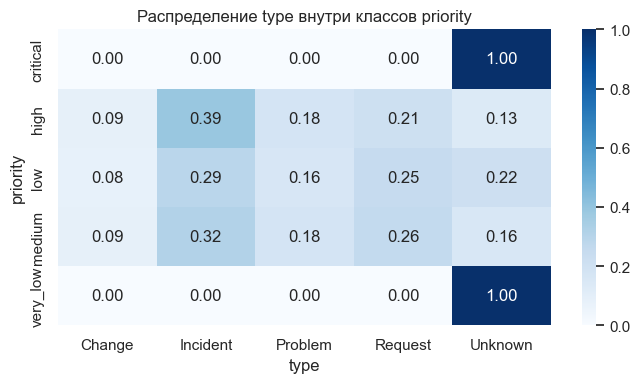

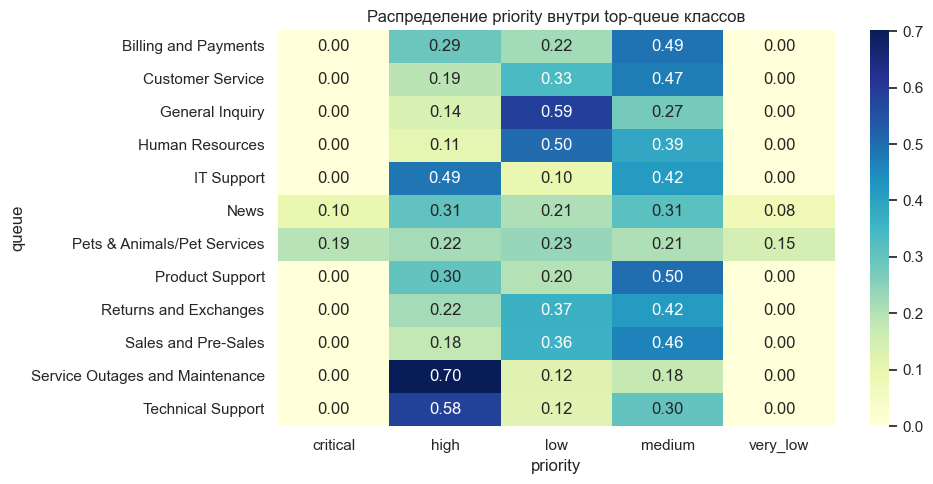

In [11]:
priority_type = pd.crosstab(train_df[priority_col], train_df[type_col], normalize="index")

plt.figure(figsize=(7, 4))
sns.heatmap(priority_type, annot=True, fmt=".2f", cmap="Blues")
plt.title("Распределение type внутри классов priority")
plt.xlabel("type")
plt.ylabel("priority")
plt.tight_layout()
plt.show()

top_queues = train_df[queue_col].value_counts().head(12).index
queue_priority = pd.crosstab(
    train_df.loc[train_df[queue_col].isin(top_queues), queue_col],
    train_df.loc[train_df[queue_col].isin(top_queues), priority_col],
    normalize="index"
)

plt.figure(figsize=(10, 5))
sns.heatmap(queue_priority, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Распределение priority внутри top-queue классов")
plt.xlabel("priority")
plt.ylabel("queue")
plt.tight_layout()
plt.show()

### Выводы по EDA

1. `queue` заметно несбалансирован, поэтому `macro F1` корректно использовать как основную метрику.
2. `body` существенно длиннее `subject`, но в `subject` часто есть ключевые триггеры маршрутизации.
3. По заданным индексам утечки между split отсутствуют.
4. Для обучения используем объединённый текст `subject + body`.

## 5. Бейзлайн для queue: TF-IDF + линейная модель

Подбор гиперпараметров выполняем по val с метрикой macro F1(queue)

In [12]:
queue_le = LabelEncoder()
y_train_q = queue_le.fit_transform(train_df[queue_col])
y_val_q = queue_le.transform(val_df[queue_col])
y_test_q = queue_le.transform(test_df[queue_col])

X_train_text = train_df["text"].tolist()
X_val_text = val_df["text"].tolist()
X_test_text = test_df["text"].tolist()

baseline_grid = [
    {"max_features": 50000, "ngram_range": (1, 1), "alpha": 1e-5, "class_weight": None},
    {"max_features": 80000, "ngram_range": (1, 2), "alpha": 1e-5, "class_weight": None},
    {"max_features": 100000, "ngram_range": (1, 2), "alpha": 5e-6, "class_weight": None},
]

baseline_trials = []

for i, cfg in enumerate(baseline_grid, 1):
    print(f"[{i}/{len(baseline_grid)}] cfg={cfg}")

    vectorizer = TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=cfg["ngram_range"],
        lowercase=True,
        strip_accents="unicode",
        min_df=3,
        max_df=0.98,
        sublinear_tf=True,
    )

    Xtr = vectorizer.fit_transform(X_train_text)
    Xv = vectorizer.transform(X_val_text)

    clf = SGDClassifier(
        loss="log_loss",
        alpha=cfg["alpha"],
        penalty="l2",
        class_weight=cfg["class_weight"],
        max_iter=2000,
        tol=1e-4,
        random_state=SEED,
        n_jobs=-1,
    )

    clf.fit(Xtr, y_train_q)
    val_pred = clf.predict(Xv)

    val_macro_f1 = f1_score(y_val_q, val_pred, average="macro")
    val_acc = accuracy_score(y_val_q, val_pred)

    baseline_trials.append({
        "cfg": cfg,
        "vectorizer": vectorizer,
        "model": clf,
        "val_macro_f1": val_macro_f1,
        "val_acc": val_acc,
    })

    print(f"val macroF1={val_macro_f1:.4f} | val acc={val_acc:.4f}\n")

baseline_val_df = pd.DataFrame([
    {
        "cfg": str(x["cfg"]),
        "val_macro_f1": x["val_macro_f1"],
        "val_acc": x["val_acc"],
    }
    for x in baseline_trials
]).sort_values("val_macro_f1", ascending=False)

display(baseline_val_df)

best_baseline = max(baseline_trials, key=lambda x: x["val_macro_f1"])
print("Лучший baseline cfg:", best_baseline["cfg"])

[1/3] cfg={'max_features': 50000, 'ngram_range': (1, 1), 'alpha': 1e-05, 'class_weight': None}
val macroF1=0.8272 | val acc=0.5717

[2/3] cfg={'max_features': 80000, 'ngram_range': (1, 2), 'alpha': 1e-05, 'class_weight': None}
val macroF1=0.8130 | val acc=0.6122

[3/3] cfg={'max_features': 100000, 'ngram_range': (1, 2), 'alpha': 5e-06, 'class_weight': None}
val macroF1=0.8551 | val acc=0.6436



,cfg,val_macro_f1,val_acc
2,"{'max_features': 100000, 'ngram_range': (1, 2)...",0.855054,0.643620
0,"{'max_features': 50000, 'ngram_range': (1, 1),...",0.827173,0.571729
1,"{'max_features': 80000, 'ngram_range': (1, 2),...",0.812985,0.612209


Лучший baseline cfg: {'max_features': 100000, 'ngram_range': (1, 2), 'alpha': 5e-06, 'class_weight': None}


In [13]:
best_vec = best_baseline["vectorizer"]
best_clf = best_baseline["model"]

Xte = best_vec.transform(X_test_text)
test_pred_q = best_clf.predict(Xte)
test_proba_q = best_clf.predict_proba(Xte)
baseline_test_conf = test_proba_q.max(axis=1)

baseline_test_macro_f1 = f1_score(y_test_q, test_pred_q, average="macro")
baseline_test_acc = accuracy_score(y_test_q, test_pred_q)

print(f"Baseline TEST macroF1(queue): {baseline_test_macro_f1:.4f}")
print(f"Baseline TEST accuracy(queue): {baseline_test_acc:.4f}")

report = classification_report(y_test_q, test_pred_q, output_dict=True, zero_division=0)
per_class = []
for i, label in enumerate(queue_le.classes_):
    d = report.get(str(i), {})
    per_class.append({
        "queue": label,
        "precision": d.get("precision", 0.0),
        "recall": d.get("recall", 0.0),
        "f1": d.get("f1-score", 0.0),
        "support": d.get("support", 0),
    })

per_class_df = pd.DataFrame(per_class)
print("\n10 классов queue с минимальным F1 на test:")
display(per_class_df.sort_values("f1").head(10))

Baseline TEST macroF1(queue): 0.8355
Baseline TEST accuracy(queue): 0.6414

10 классов queue с минимальным F1 на test:


,queue,precision,recall,f1,support
23,Human Resources,0.923077,0.131868,0.230769,91.0
16,General Inquiry,1.000000,0.142857,0.250000,63.0
41,Returns and Exchanges,0.706667,0.218107,0.333333,243.0
42,Sales and Pre-Sales,0.788462,0.297101,0.431579,138.0
28,IT Support,0.550532,0.401942,0.464646,515.0
10,Customer Service,0.487952,0.528721,0.507519,766.0
39,Product Support,0.524176,0.509072,0.516513,937.0
45,Service Outages and Maintenance,0.841121,0.489130,0.618557,184.0
49,Technical Support,0.528275,0.770804,0.626900,1418.0
37,Pets & Animals/Pet Services,0.827586,0.685714,0.750000,35.0


## 6. Мультитаск-модель на трансформере

Здесь реализован multitask fine-tuning:
- общий encoder (`distilbert-base-multilingual-cased`),
- три отдельных лейбла: `queue`, `priority`, `type`,
- совместная оптимизация суммарного лосса: `w_q * CE(queue) + CE(priority) + CE(type)`


Для экономии вычислений используем небольшой список конфигураций,
каждую обучаем по 1 эпохе, и выбираем лучшую по `val_macroF1(queue)`.

In [14]:
queue_le_mt = LabelEncoder()
priority_le_mt = LabelEncoder()
type_le_mt = LabelEncoder()

train_df["y_queue"] = queue_le_mt.fit_transform(train_df[queue_col])
val_df["y_queue"] = queue_le_mt.transform(val_df[queue_col])
test_df["y_queue"] = queue_le_mt.transform(test_df[queue_col])

train_df["y_priority"] = priority_le_mt.fit_transform(train_df[priority_col])
val_df["y_priority"] = priority_le_mt.transform(val_df[priority_col])
test_df["y_priority"] = priority_le_mt.transform(test_df[priority_col])

train_df["y_type"] = type_le_mt.fit_transform(train_df[type_col])
val_df["y_type"] = type_le_mt.transform(val_df[type_col])
test_df["y_type"] = type_le_mt.transform(test_df[type_col])

n_queue = len(queue_le_mt.classes_)
n_priority = len(priority_le_mt.classes_)
n_type = len(type_le_mt.classes_)

print(f"Число классов queue: {n_queue}")
print(f"Число классов priority: {n_priority}")
print(f"Число классов type: {n_type}")
print("Классы type:", list(type_le_mt.classes_))

Число классов queue: 52
Число классов priority: 5
Число классов type: 5
Классы type: ['Change', 'Incident', 'Problem', 'Request', 'Unknown']


In [15]:
MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LEN = 128

# Размеры выборок для обучения выбранной конфигурации трансформера
MT_TRAIN_SIZE = 10000
MT_VAL_SIZE = 2000

UNFREEZE_LAST_N = 2
QUEUE_LOSS_WEIGHT = 1.5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.yq = torch.tensor(df["y_queue"].values, dtype=torch.long)
        self.yp = torch.tensor(df["y_priority"].values, dtype=torch.long)
        self.yt = torch.tensor(df["y_type"].values, dtype=torch.long)

        enc = tokenizer(
            df["text"].tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]

    def __len__(self):
        return len(self.yq)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels_queue": self.yq[idx],
            "labels_priority": self.yp[idx],
            "labels_type": self.yt[idx],
        }


class MultiTaskTicketModel(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.head_queue = nn.Linear(hidden, n_queue)
        self.head_priority = nn.Linear(hidden, n_priority)
        self.head_type = nn.Linear(hidden, n_type)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]
        pooled = self.dropout(pooled)

        logits_q = self.head_queue(pooled)
        logits_p = self.head_priority(pooled)
        logits_t = self.head_type(pooled)
        return logits_q, logits_p, logits_t


def set_trainable_layers(model, n_last_layers=2):
    # Замораживаем encoder
    for p in model.encoder.parameters():
        p.requires_grad = False

    # Размораживаем последние N слоёв (для DistilBERT)
    if hasattr(model.encoder, "transformer") and hasattr(model.encoder.transformer, "layer"):
        layers = model.encoder.transformer.layer
        n = min(n_last_layers, len(layers))
        for layer in layers[-n:]:
            for p in layer.parameters():
                p.requires_grad = True
    else:
        # Fallback: если структура иная, обучаем encoder полностью
        for p in model.encoder.parameters():
            p.requires_grad = True

    # Головы всегда обучаем
    for p in model.head_queue.parameters():
        p.requires_grad = True
    for p in model.head_priority.parameters():
        p.requires_grad = True
    for p in model.head_type.parameters():
        p.requires_grad = True

In [16]:
def make_subset(df, n_rows, seed=42):
    n_rows = min(n_rows, len(df))
    return df.sample(n=n_rows, random_state=seed).reset_index(drop=True)


def make_loaders(batch_size, train_data, val_data, test_data):
    train_ds = TicketDataset(train_data, tokenizer, MAX_LEN)
    val_ds = TicketDataset(val_data, tokenizer, MAX_LEN)
    test_ds = TicketDataset(test_data, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()

    yq_true, yq_pred, yq_conf = [], [], []
    yp_true, yp_pred = [], []
    yt_true, yt_pred = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        lq, lp, lt = model(input_ids=input_ids, attention_mask=attention_mask)

        pq = torch.softmax(lq, dim=1)
        pred_q = torch.argmax(pq, dim=1)
        pred_p = torch.argmax(lp, dim=1)
        pred_t = torch.argmax(lt, dim=1)

        yq_true.extend(batch["labels_queue"].cpu().numpy())
        yq_pred.extend(pred_q.cpu().numpy())
        yq_conf.extend(torch.max(pq, dim=1).values.cpu().numpy())

        yp_true.extend(batch["labels_priority"].cpu().numpy())
        yp_pred.extend(pred_p.cpu().numpy())

        yt_true.extend(batch["labels_type"].cpu().numpy())
        yt_pred.extend(pred_t.cpu().numpy())

    yq_true = np.array(yq_true)
    yq_pred = np.array(yq_pred)
    yq_conf = np.array(yq_conf)
    yp_true = np.array(yp_true)
    yp_pred = np.array(yp_pred)
    yt_true = np.array(yt_true)
    yt_pred = np.array(yt_pred)

    metrics = {
        "macro_f1_queue": f1_score(yq_true, yq_pred, average="macro"),
        "acc_queue": accuracy_score(yq_true, yq_pred),
        "acc_priority": accuracy_score(yp_true, yp_pred),
        "acc_type": accuracy_score(yt_true, yt_pred),
    }

    preds = {
        "yq_true": yq_true,
        "yq_pred": yq_pred,
        "yq_conf": yq_conf,
        "yp_true": yp_true,
        "yp_pred": yp_pred,
        "yt_true": yt_true,
        "yt_pred": yt_pred,
    }
    return metrics, preds

In [17]:
# Короткий подбор: несколько конфигураций по 1 эпохе
search_space = [
    {"lr": 2e-5, "batch_size": 16, "epochs": 1, "weight_decay": 0.01},
    {"lr": 3e-5, "batch_size": 16, "epochs": 1, "weight_decay": 0.01},
    {"lr": 2e-5, "batch_size": 24, "epochs": 1, "weight_decay": 0.01},
]

train_tune_df = make_subset(train_df, MT_TRAIN_SIZE, seed=SEED)
val_tune_df = make_subset(val_df, MT_VAL_SIZE, seed=SEED)

print(f"Train для подбора: {len(train_tune_df):,}")
print(f"Val для подбора:   {len(val_tune_df):,}")

os.makedirs("artifacts", exist_ok=True)
BEST_PATH = "artifacts/best_multitask_model.pt"

criterion = nn.CrossEntropyLoss()
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

best_val_f1 = -1.0
best_cfg = None
mt_history = []

for cfg_id, cfg in enumerate(search_space, 1):
    print(f"\n=== Конфигурация {cfg_id}/{len(search_space)}: {cfg} ===")
    seed_everything(SEED)

    train_loader, val_loader, _ = make_loaders(
        batch_size=cfg["batch_size"],
        train_data=train_tune_df,
        val_data=val_tune_df,
        test_data=test_df,
    )

    model = MultiTaskTicketModel(
        model_name=MODEL_NAME,
        n_queue=n_queue,
        n_priority=n_priority,
        n_type=n_type,
    ).to(device)

    set_trainable_layers(model, n_last_layers=UNFREEZE_LAST_N)
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )

    total_steps = max(1, len(train_loader) * cfg["epochs"])
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        losses = []

        for batch in tqdm(train_loader, desc=f"cfg{cfg_id} epoch{epoch}", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            yq = batch["labels_queue"].to(device)
            yp = batch["labels_priority"].to(device)
            yt = batch["labels_type"].to(device)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast(enabled=True):
                    lq, lp, lt = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss_q = criterion(lq, yq)
                    loss_p = criterion(lp, yp)
                    loss_t = criterion(lt, yt)
                    loss = QUEUE_LOSS_WEIGHT * loss_q + loss_p + loss_t
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                lq, lp, lt = model(input_ids=input_ids, attention_mask=attention_mask)
                loss_q = criterion(lq, yq)
                loss_p = criterion(lp, yp)
                loss_t = criterion(lt, yt)
                loss = QUEUE_LOSS_WEIGHT * loss_q + loss_p + loss_t
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            losses.append(loss.item())

        val_metrics, _ = evaluate_model(model, val_loader)
        avg_loss = float(np.mean(losses)) if losses else np.nan

        print(
            f"epoch={epoch} | train_loss={avg_loss:.4f} | "
            f"val_macroF1(queue)={val_metrics['macro_f1_queue']:.4f} | "
            f"val_acc(queue)={val_metrics['acc_queue']:.4f}"
        )

        mt_history.append({
            "cfg": cfg,
            "epoch": epoch,
            "train_loss": avg_loss,
            **val_metrics,
        })

        if val_metrics["macro_f1_queue"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1_queue"]
            best_cfg = cfg.copy()
            torch.save(model.state_dict(), BEST_PATH)

print("\nЛучший val macroF1(queue):", round(best_val_f1, 4))
print("Лучшая конфигурация:", best_cfg)
print("Путь к чекпоинту:", BEST_PATH)

Train для подбора: 10,000
Val для подбора:   2,000

=== Конфигурация 1/3: {'lr': 2e-05, 'batch_size': 16, 'epochs': 1, 'weight_decay': 0.01} ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9004.90it/s]


epoch=1 | train_loss=6.0862 | val_macroF1(queue)=0.0311 | val_acc(queue)=0.2705

=== Конфигурация 2/3: {'lr': 3e-05, 'batch_size': 16, 'epochs': 1, 'weight_decay': 0.01} ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 12129.98it/s]


epoch=1 | train_loss=5.8905 | val_macroF1(queue)=0.0291 | val_acc(queue)=0.2780

=== Конфигурация 3/3: {'lr': 2e-05, 'batch_size': 24, 'epochs': 1, 'weight_decay': 0.01} ===


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 15803.71it/s]


epoch=1 | train_loss=6.2459 | val_macroF1(queue)=0.0273 | val_acc(queue)=0.2640

Лучший val macroF1(queue): 0.0311
Лучшая конфигурация: {'lr': 2e-05, 'batch_size': 16, 'epochs': 1, 'weight_decay': 0.01}
Путь к чекпоинту: artifacts/best_multitask_model.pt


In [18]:
# Оценка лучшей мультитаск-модели на полном test
_, _, test_loader_mt = make_loaders(
    batch_size=best_cfg["batch_size"],
    train_data=train_tune_df,
    val_data=val_tune_df,
    test_data=test_df,
)

best_mt_model = MultiTaskTicketModel(
    model_name=MODEL_NAME,
    n_queue=n_queue,
    n_priority=n_priority,
    n_type=n_type,
).to(device)
best_mt_model.load_state_dict(torch.load(BEST_PATH, map_location=device))

mt_test_metrics, mt_test_preds = evaluate_model(best_mt_model, test_loader_mt)

mt_score = (
    0.70 * mt_test_metrics["macro_f1_queue"]
    + 0.15 * mt_test_metrics["acc_priority"]
    + 0.15 * mt_test_metrics["acc_type"]
)
mt_model_tag = "Multitask Transformer (trained in notebook)"

print("TEST-метрики мультитаск-модели:")
print(f"macro F1(queue):    {mt_test_metrics['macro_f1_queue']:.4f}")
print(f"accuracy(queue):    {mt_test_metrics['acc_queue']:.4f}")
print(f"accuracy(priority): {mt_test_metrics['acc_priority']:.4f}")
print(f"accuracy(type):     {mt_test_metrics['acc_type']:.4f}")
print(f"Итоговый Score:     {mt_score:.4f}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11098.98it/s]


TEST-метрики мультитаск-модели:
macro F1(queue):    0.0291
accuracy(queue):    0.2571
accuracy(priority): 0.4452
accuracy(type):     0.7656
Итоговый Score:     0.2020


### Использование готового чекпоинта полученного в среде с большими мощностями (без повторного обучения), в pull request не прикреплял, так как много весит

Есть заранее обученный чекпоинт, ноутбук сначала ищет его локально в рабочей среде:
best_multitask_premodel.pt
Найденный чекпоинт используется для пересчёта test-метрик и дальнейшего анализа.

In [19]:
candidate_ckpts = [
    Path('best_multitask_premodel.pt'),
    Path('artifacts/best_multitask_model.pt'),
]
external_ckpt_path = next((p for p in candidate_ckpts if p.exists()), None)

if external_ckpt_path is not None:
    print(f"Найден внешний чекпоинт: {external_ckpt_path}")

    external_model = MultiTaskTicketModel(
        model_name=MODEL_NAME,
        n_queue=n_queue,
        n_priority=n_priority,
        n_type=n_type,
    ).to(device)
    external_model.load_state_dict(torch.load(external_ckpt_path, map_location=device))

    _, _, test_loader_ext = make_loaders(
        batch_size=16,
        train_data=train_df,
        val_data=val_df,
        test_data=test_df,
    )

    ext_metrics, ext_preds = evaluate_model(external_model, test_loader_ext)
    ext_score = (
        0.70 * ext_metrics["macro_f1_queue"]
        + 0.15 * ext_metrics["acc_priority"]
        + 0.15 * ext_metrics["acc_type"]
    )

    print("\nTEST-метрики внешнего чекпоинта:")
    print(f"macro F1(queue):    {ext_metrics['macro_f1_queue']:.4f}")
    print(f"accuracy(queue):    {ext_metrics['acc_queue']:.4f}")
    print(f"accuracy(priority): {ext_metrics['acc_priority']:.4f}")
    print(f"accuracy(type):     {ext_metrics['acc_type']:.4f}")
    print(f"Итоговый Score:     {ext_score:.4f}")

    mt_test_metrics = ext_metrics
    mt_test_preds = ext_preds
    mt_score = ext_score
    mt_model_tag = f"Multitask Transformer (external ckpt: {external_ckpt_path.name})"

else:
    print("Внешний чекпоинт не найден. Используются метрики модели, обученной внутри ноутбука.")

Найден внешний чекпоинт: best_multitask_premodel.pt


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13624.06it/s]



TEST-метрики внешнего чекпоинта:
macro F1(queue):    0.8333
accuracy(queue):    0.5786
accuracy(priority): 0.6294
accuracy(type):     0.8706
Итоговый Score:     0.8083


## 7. Сравнение моделей

In [20]:
comparison = pd.DataFrame([
    {
        "model": "TF-IDF + SGD (queue)",
        "macroF1_queue": baseline_test_macro_f1,
        "acc_queue": baseline_test_acc,
        "acc_priority": np.nan,
        "acc_type": np.nan,
        "score": np.nan,
    },
    {
        "model": mt_model_tag,
        "macroF1_queue": mt_test_metrics["macro_f1_queue"],
        "acc_queue": mt_test_metrics["acc_queue"],
        "acc_priority": mt_test_metrics["acc_priority"],
        "acc_type": mt_test_metrics["acc_type"],
        "score": mt_score,
    },
])

display(comparison)

best_queue_model_name = (
    "TF-IDF + SGD (queue)"
    if baseline_test_macro_f1 >= mt_test_metrics["macro_f1_queue"]
    else mt_model_tag
)
print(f"Лучшая модель по queue на test: {best_queue_model_name}")

,model,macroF1_queue,acc_queue,acc_priority,acc_type,score
0,TF-IDF + SGD (queue),0.835466,0.641412,NaN,NaN,NaN
1,Multitask Transformer (external ckpt: best_mul...,0.833328,0.578598,0.629432,0.870649,0.808342


Лучшая модель по queue на test: TF-IDF + SGD (queue)


## 8. Дополнительные эксперименты

1. Лёгкая очистка текста для TF-IDF baseline.
2. KNN-классификатор по TF-IDF-признакам (через SVD-сжатие) как альтернативный метод для `queue`.

In [21]:
def light_clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Эксперимент 1: очистка текста + линейная модель
train_clean = [light_clean(x) for x in X_train_text]
val_clean = [light_clean(x) for x in X_val_text]
test_clean = [light_clean(x) for x in X_test_text]

vec_clean = TfidfVectorizer(
    max_features=80000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.98,
    sublinear_tf=True,
)

Xtr_c = vec_clean.fit_transform(train_clean)
Xv_c = vec_clean.transform(val_clean)
Xte_c = vec_clean.transform(test_clean)

clf_clean = SGDClassifier(
    loss="log_loss",
    alpha=5e-6,
    max_iter=2000,
    tol=1e-4,
    random_state=SEED,
    n_jobs=-1,
)
clf_clean.fit(Xtr_c, y_train_q)

val_pred_c = clf_clean.predict(Xv_c)
test_pred_c = clf_clean.predict(Xte_c)

print("[Clean TF-IDF] Val macroF1:", round(f1_score(y_val_q, val_pred_c, average="macro"), 4))
print("[Clean TF-IDF] Test macroF1:", round(f1_score(y_test_q, test_pred_c, average="macro"), 4))


# Эксперимент 2: KNN на сжатых TF-IDF признаках
knn_train_size = 20000
knn_idx = train_df.sample(n=min(knn_train_size, len(train_df)), random_state=SEED).index

Xtr_knn_sparse = best_vec.transform(train_df.loc[knn_idx, "text"].tolist())
ytr_knn = y_train_q[knn_idx]
Xv_knn_sparse = best_vec.transform(X_val_text)
Xte_knn_sparse = best_vec.transform(X_test_text)

svd = TruncatedSVD(n_components=128, random_state=SEED)
Xtr_knn = svd.fit_transform(Xtr_knn_sparse)
Xv_knn = svd.transform(Xv_knn_sparse)
Xte_knn = svd.transform(Xte_knn_sparse)

knn_grid = [3, 5, 9]
knn_trials = []

for k in knn_grid:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", metric="minkowski", p=2)
    knn.fit(Xtr_knn, ytr_knn)
    val_pred_knn = knn.predict(Xv_knn)

    val_f1 = f1_score(y_val_q, val_pred_knn, average="macro")
    val_acc = accuracy_score(y_val_q, val_pred_knn)
    knn_trials.append((k, knn, val_f1, val_acc))
    print(f"[KNN k={k}] Val macroF1={val_f1:.4f} | Val acc={val_acc:.4f}")

best_k, best_knn, best_knn_val_f1, best_knn_val_acc = max(knn_trials, key=lambda x: x[2])
test_pred_knn = best_knn.predict(Xte_knn)
knn_test_f1 = f1_score(y_test_q, test_pred_knn, average="macro")
knn_test_acc = accuracy_score(y_test_q, test_pred_knn)

print(f"\n[KNN best] k={best_k}")
print(f"[KNN best] Test macroF1(queue): {knn_test_f1:.4f}")
print(f"[KNN best] Test accuracy(queue): {knn_test_acc:.4f}")

[Clean TF-IDF] Val macroF1: 0.8505
[Clean TF-IDF] Test macroF1: 0.8317
[KNN k=3] Val macroF1=0.3517 | Val acc=0.4373
[KNN k=5] Val macroF1=0.3256 | Val acc=0.4202
[KNN k=9] Val macroF1=0.2906 | Val acc=0.3960

[KNN best] k=3
[KNN best] Test macroF1(queue): 0.3345
[KNN best] Test accuracy(queue): 0.4358


## 9. Анализ ошибок

Для анализа ошибок по `queue` используем модель, которая лучше на test по `macro F1(queue)`.

In [22]:
if baseline_test_macro_f1 >= mt_test_metrics["macro_f1_queue"]:
    analysis_source = "TF-IDF + SGD (queue)"
    analysis_true = y_test_q
    analysis_pred = test_pred_q
    analysis_conf = baseline_test_conf
    decode_queue = queue_le.inverse_transform
else:
    analysis_source = "Multitask Transformer"
    analysis_true = mt_test_preds["yq_true"]
    analysis_pred = mt_test_preds["yq_pred"]
    analysis_conf = mt_test_preds["yq_conf"]
    decode_queue = queue_le_mt.inverse_transform

print(f"Модель для error-анализа: {analysis_source}")

err_mask = analysis_true != analysis_pred
err_idx = np.where(err_mask)[0]

errors_df = pd.DataFrame({
    "idx": err_idx,
    "confidence": analysis_conf[err_idx],
    "y_true": decode_queue(analysis_true[err_idx]),
    "y_pred": decode_queue(analysis_pred[err_idx]),
}).sort_values("confidence", ascending=False)

print("Топ-15 самых уверенных ошибок:")
show_df = errors_df.head(15).copy()
if len(show_df) > 0:
    rows = test_df.iloc[show_df["idx"].values][[subject_col, body_col]].reset_index(drop=True)
    display(pd.concat([show_df.reset_index(drop=True), rows], axis=1))
else:
    print("Ошибок не найдено.")

Модель для error-анализа: TF-IDF + SGD (queue)
Топ-15 самых уверенных ошибок:


,idx,confidence,y_true,y_pred,subject,body
0,1672,0.838181,Product Support,Technical Support,Problem with Software Crash,An unexpected crash happened during data analy...
1,1697,0.761920,Product Support,Service Outages and Maintenance,Assistance with Service Interruption,An unforeseen service disruption impacted proj...
2,1062,0.759449,IT Support,Technical Support,Problem with Analytics Dashboard Display,The analytics dashboard is showing incorrect i...
3,1230,0.757863,Product Support,Technical Support,Problem with Software Crashes During Data Anal...,"Hello Customer Support, our company has been e..."
4,860,0.749484,Customer Service,Technical Support,,"Customer Support, composing a report regarding..."
5,4613,0.746170,Customer Service,Technical Support,Request for Support in Integrating Microsoft A...,Seeking detailed guidance on integrating the M...
6,2236,0.745083,IT Support,Technical Support,Data Integrity Issue,Significant data integrity problem detected in...
7,4901,0.745083,IT Support,Technical Support,Data Integrity Issue,Significant data integrity problem detected in...
8,5452,0.734581,IT Support,Technical Support,Support Request for Antivirus Software Update ...,I am reaching out to seek assistance in updati...
9,5903,0.729647,Service Outages and Maintenance,Technical Support,Problem with Website Integrations Malfunction,Our website and social media integrations have...


## 10. Анализ уверенности (confidence)

Считаем качество по всем долям автоматизации:
- `auto_macro_f1`: macro F1 на автоматически обработанной части (top-X% по уверенности),
- `hybrid_macro_f1`: гипотетический macro F1 на всём test, если оставшиеся `(1-X)%` вручную размечаются идеально.

Confidence-анализ для модели: TF-IDF + SGD (queue)


,auto_share,manual_share,auto_tickets,auto_macro_f1,auto_acc,hybrid_macro_f1,hybrid_acc,delta_auto_f1_vs_100,delta_auto_acc_vs_100,delta_hybrid_f1_vs_100
0,0.10,0.90,617,0.977940,0.972447,0.999538,0.997248,0.142475,0.331036,0.164072
1,0.15,0.85,926,0.966380,0.952484,0.998583,0.992877,0.130914,0.311072,0.163117
2,0.20,0.80,1235,0.944476,0.930364,0.996951,0.986077,0.109010,0.288953,0.161485
3,0.25,0.75,1544,0.952147,0.908031,0.995084,0.977011,0.116682,0.266619,0.159619
4,0.30,0.70,1853,0.949269,0.881274,0.992663,0.964384,0.113803,0.239862,0.157197
5,0.35,0.65,2161,0.945964,0.862101,0.989819,0.951757,0.110499,0.220689,0.154354
6,0.40,0.60,2470,0.938590,0.847773,0.985901,0.939129,0.103124,0.206362,0.150436
7,0.45,0.55,2779,0.933976,0.823678,0.981840,0.920673,0.098510,0.182266,0.146374
8,0.50,0.50,3088,0.929299,0.801813,0.977468,0.900923,0.093833,0.160402,0.142003
9,0.55,0.45,3397,0.921601,0.781278,0.971127,0.879715,0.086135,0.139866,0.135661


Сводная таблица по ключевым долям:


,auto_share,manual_share,auto_macro_f1,delta_auto_f1_vs_100,hybrid_macro_f1,delta_hybrid_f1_vs_100
8,0.5,0.5,0.929299,0.093833,0.977468,0.142003
10,0.6,0.4,0.916381,0.080916,0.964440,0.128975
12,0.7,0.3,0.911915,0.076449,0.952689,0.117223
14,0.8,0.2,0.903005,0.067539,0.934280,0.098815
16,0.9,0.1,0.889512,0.054046,0.908137,0.072671
18,1.0,0.0,0.835466,0.000000,0.835466,0.000000


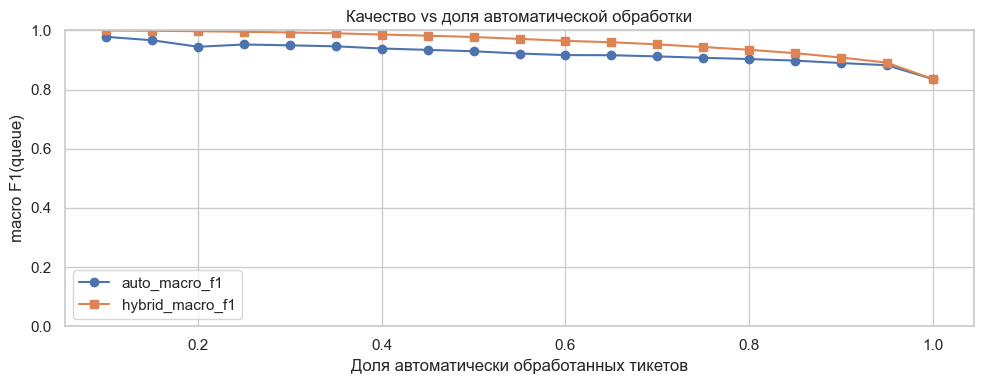

Для 70/30:
auto_macro_f1(70%):   0.9119
hybrid_macro_f1(70%): 0.9527


In [23]:
y_true = analysis_true
y_pred = analysis_pred
conf = analysis_conf

order = np.argsort(-conf)

def metrics_for_fraction(frac):
    k = max(1, int(len(order) * frac))
    auto_idx = order[:k]

    auto_f1 = f1_score(y_true[auto_idx], y_pred[auto_idx], average="macro")
    auto_acc = accuracy_score(y_true[auto_idx], y_pred[auto_idx])

    # Гипотеза: manual-часть размечается идеально
    hybrid_pred = y_true.copy()
    hybrid_pred[auto_idx] = y_pred[auto_idx]
    hybrid_f1 = f1_score(y_true, hybrid_pred, average="macro")
    hybrid_acc = accuracy_score(y_true, hybrid_pred)

    return auto_f1, auto_acc, hybrid_f1, hybrid_acc, k

fractions = np.round(np.arange(0.10, 1.01, 0.05), 2)
rows = []

for frac in fractions:
    auto_f1, auto_acc, hybrid_f1, hybrid_acc, k = metrics_for_fraction(frac)
    rows.append({
        "auto_share": frac,
        "manual_share": round(1 - frac, 2),
        "auto_tickets": int(k),
        "auto_macro_f1": auto_f1,
        "auto_acc": auto_acc,
        "hybrid_macro_f1": hybrid_f1,
        "hybrid_acc": hybrid_acc,
    })

confidence_curve = pd.DataFrame(rows)

# Добавляем изменения относительно режима 100% авто
full_auto_f1 = confidence_curve.loc[np.isclose(confidence_curve["auto_share"], 1.0), "auto_macro_f1"].iloc[0]
full_auto_acc = confidence_curve.loc[np.isclose(confidence_curve["auto_share"], 1.0), "auto_acc"].iloc[0]

confidence_curve["delta_auto_f1_vs_100"] = confidence_curve["auto_macro_f1"] - full_auto_f1
confidence_curve["delta_auto_acc_vs_100"] = confidence_curve["auto_acc"] - full_auto_acc
confidence_curve["delta_hybrid_f1_vs_100"] = confidence_curve["hybrid_macro_f1"] - full_auto_f1

print(f"Confidence-анализ для модели: {analysis_source}")

display(confidence_curve)

summary_shares = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
summary_table = confidence_curve[confidence_curve["auto_share"].isin(summary_shares)].copy()
summary_table = summary_table[[
    "auto_share",
    "manual_share",
    "auto_macro_f1",
    "delta_auto_f1_vs_100",
    "hybrid_macro_f1",
    "delta_hybrid_f1_vs_100",
]]

print("Сводная таблица по ключевым долям:")
display(summary_table)

plt.figure(figsize=(10, 4))
plt.plot(confidence_curve["auto_share"], confidence_curve["auto_macro_f1"], marker="o", label="auto_macro_f1")
plt.plot(confidence_curve["auto_share"], confidence_curve["hybrid_macro_f1"], marker="s", label="hybrid_macro_f1")
plt.title("Качество vs доля автоматической обработки")
plt.xlabel("Доля автоматически обработанных тикетов")
plt.ylabel("macro F1(queue)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

row70 = confidence_curve.loc[np.isclose(confidence_curve["auto_share"], 0.70)].iloc[0]
print("Для 70/30:")
print(f"auto_macro_f1(70%):   {row70['auto_macro_f1']:.4f}")
print(f"hybrid_macro_f1(70%): {row70['hybrid_macro_f1']:.4f}")

In [24]:
# Короткая автоматическая сводка по confidence-кривой
best_auto_row = confidence_curve.loc[confidence_curve['auto_macro_f1'].idxmax()]
best_hybrid_row = confidence_curve.loc[confidence_curve['hybrid_macro_f1'].idxmax()]
row70 = confidence_curve.loc[np.isclose(confidence_curve['auto_share'], 0.70)].iloc[0]

print(f"Лучшая auto-точка: auto_share={best_auto_row['auto_share']:.2f}, auto_macro_f1={best_auto_row['auto_macro_f1']:.4f}")
print(f"Лучшая hybrid-точка: auto_share={best_hybrid_row['auto_share']:.2f}, hybrid_macro_f1={best_hybrid_row['hybrid_macro_f1']:.4f}")
print(f"Точка 70/30: auto_macro_f1={row70['auto_macro_f1']:.4f}, hybrid_macro_f1={row70['hybrid_macro_f1']:.4f}")

Лучшая auto-точка: auto_share=0.10, auto_macro_f1=0.9779
Лучшая hybrid-точка: auto_share=0.10, hybrid_macro_f1=0.9995
Точка 70/30: auto_macro_f1=0.9119, hybrid_macro_f1=0.9527


## 11. Общий вывод

1. Лучший baseline для основной задачи `queue` на test:
- `macro F1(queue) = 0.8355`
- `accuracy(queue) = 0.6414`

2. По confidence-анализу (для лучшей queue-модели):
- при `100%` автообработке: `auto_macro_f1 = 0.8355`
- при `70/30`: `auto_macro_f1 = 0.9119`, `hybrid_macro_f1 = 0.9527`
- прирост `auto_macro_f1` в точке 70/30 относительно 100% авто: `+0.0764`

3. Практический вывод: при передаче части сложных тикетов в ручную обработку качество маршрутизации существенно растёт.

In [25]:
print("Итоговая сводка по текущему запуску:")

if 'baseline_test_macro_f1' in globals() and 'baseline_test_acc' in globals():
    print(f"Baseline queue: macroF1={baseline_test_macro_f1:.4f}, acc={baseline_test_acc:.4f}")

if 'mt_test_metrics' in globals() and 'mt_score' in globals():
    print(
        "Multitask: "
        f"macroF1(queue)={mt_test_metrics['macro_f1_queue']:.4f}, "
        f"acc(queue)={mt_test_metrics['acc_queue']:.4f}, "
        f"acc(priority)={mt_test_metrics['acc_priority']:.4f}, "
        f"acc(type)={mt_test_metrics['acc_type']:.4f}, "
        f"score={mt_score:.4f}"
    )

if 'confidence_curve' in globals():
    row70 = confidence_curve.loc[np.isclose(confidence_curve['auto_share'], 0.70)].iloc[0]
    row100 = confidence_curve.loc[np.isclose(confidence_curve['auto_share'], 1.00)].iloc[0]
    print(
        "Confidence 70/30: "
        f"auto_macro_f1={row70['auto_macro_f1']:.4f}, "
        f"hybrid_macro_f1={row70['hybrid_macro_f1']:.4f}, "
        f"delta_vs_100={row70['delta_auto_f1_vs_100']:.4f}"
    )
    print(f"Confidence 100/0: auto_macro_f1={row100['auto_macro_f1']:.4f}")

Итоговая сводка по текущему запуску:
Baseline queue: macroF1=0.8355, acc=0.6414
Multitask: macroF1(queue)=0.8333, acc(queue)=0.5786, acc(priority)=0.6294, acc(type)=0.8706, score=0.8083
Confidence 70/30: auto_macro_f1=0.9119, hybrid_macro_f1=0.9527, delta_vs_100=0.0764
Confidence 100/0: auto_macro_f1=0.8355
